In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')

In [16]:
df=pd.read_csv('/kaggle/input/datasets/mounikaneelam13/food-delivery/Food_Delivery_Times.csv')

In [17]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [20]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [22]:
df.shape

(1000, 9)

In [23]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [24]:
df.isnull().sum()

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

In [27]:
label_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

encoders = {}
for col in label_cols:
    encoders[col] = LabelEncoder()
    df[col] = encoders[col].fit_transform(df[col])

In [29]:
df['Courier_Experience_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median())

In [30]:
df.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [31]:
X = df.drop(['Order_ID', 'Delivery_Time_min'], axis=1)
y = df['Delivery_Time_min']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [34]:
model =LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [35]:
print("Weight:", model.coef_[0])
print("Bias:", model.intercept_)

Weight: 3.0283672773461356
Bias: 12.672448399127397


In [36]:
y_pred = model.predict(X_test)

In [37]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,32,39.840968
1,68,62.638224
2,39,37.772288
3,44,48.806286
4,85,93.889965
5,31,35.544416
6,77,62.698315
7,33,34.630423
8,90,28.768236
9,91,70.129732


In [38]:
#avg of how wrong model predicts
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 7.309149015283481


In [39]:
#highlights wrong errors strongly
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 10.490738277537668


In [40]:
#measures how model explains data correctly
r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.7544645999768445


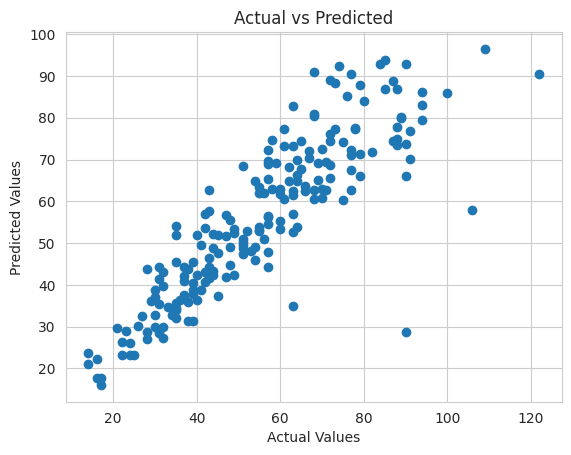

In [43]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

In [45]:
X = df[
    [
        "Distance_km",
        "Weather",
        "Traffic_Level",
        "Time_of_Day",
        "Vehicle_Type",
        "Preparation_Time_min"
    ]
]

y = df["Delivery_Time_min"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [47]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

LinearRegression()

In [48]:
print("Weights:", multi_model.coef_)
print("Bias:", multi_model.intercept_)

Weights: [ 3.0249501   1.38106589 -1.38725686  0.22548887 -0.29066853  1.00297336]
Bias: 9.173861695688636


In [49]:
y_pred_multi = multi_model.predict(X_test)

In [50]:
mae_multi = mean_absolute_error(
    y_test,
    y_pred_multi
)

print("Multiple Regression MAE:", mae_multi)

Multiple Regression MAE: 7.220897813693472


In [51]:
rmse_multi = np.sqrt(
    mean_squared_error(y_test, y_pred_multi)
)

print("Multiple Regression RMSE:", rmse_multi)

Multiple Regression RMSE: 10.522240316608727


In [52]:
r2_multi = r2_score(
    y_test,
    y_pred_multi
)

print("Multiple Regression R²:", r2_multi)

Multiple Regression R²: 0.7529877774971796


In [53]:
comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae,
        mae_multi
    ],
    "RMSE": [
        rmse,
        rmse_multi
    ],
    "R2": [
        r2,
        r2_multi
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Simple Linear Regression,7.309149,10.490738,0.754465
1,Multiple Linear Regression,7.220898,10.522240,0.752988


In [54]:
X = df[["Distance_km"]]
y = df["Delivery_Time_min"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [57]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [58]:
y_pred_poly = poly_model.predict(X_test_poly)

In [59]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_poly = mean_absolute_error(y_t est, y_pred_poly)

rmse_poly = np.sqrt(
    mean_squared_error(y_test, y_pred_poly)
)

r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial MAE:", mae_poly)
print("Polynomial RMSE:", rmse_poly)
print("Polynomial R²:", r2_poly)

Polynomial MAE: 9.614793173171334
Polynomial RMSE: 12.584097190698738
Polynomial R²: 0.6466979656792144


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


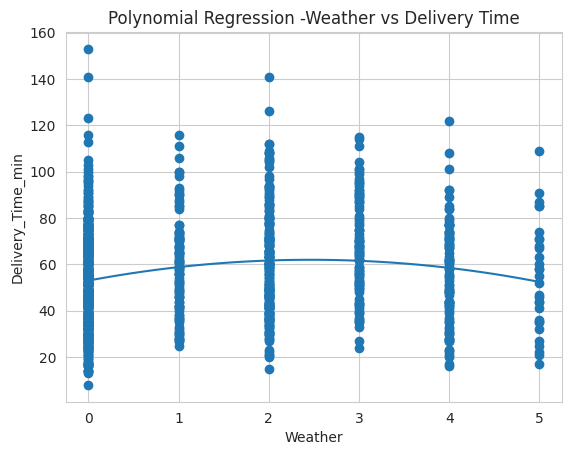

In [62]:
# X and y
X = df[["Weather"]]
y = df["Delivery_Time_min"]

# Polynomial features
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

# Train model
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Create smooth temperature range
temperature_range = np.linspace(
    X["Weather"].min(),
    X["Weather"].max(),
    100
).reshape(-1, 1)

# Convert temperature range into polynomial features
temperature_range_poly = poly.transform(temperature_range)

# Predict delivery time
curve_predictions = poly_model.predict(
    temperature_range_poly
)

# Plot
plt.scatter(X, y)
plt.plot(temperature_range, curve_predictions)

plt.xlabel("Weather")
plt.ylabel("Delivery_Time_min")
plt.title("Polynomial Regression -Weather vs Delivery Time")

plt.show()

In [63]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

results = []

for degree in range(1, 9):

    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    mse = mean_squared_error(y_test, y_pred)

    results.append([degree, mse])

results

[[1, 158.16196727280166],
 [2, 158.3595021049519],
 [3, 158.206515181905],
 [4, 157.00730345838403],
 [5, 156.85078640818358],
 [6, 156.64151725653358],
 [7, 156.80969111037408],
 [8, 157.4096380093272]]

In [64]:
results_df = pd.DataFrame(
    results,
    columns=["Degree", "Test_MSE"]
)

results_df
best_degree = results_df.loc[
    results_df["Test_MSE"].idxmin(),
    "Degree"
]

print("Best degree:", best_degree)

Best degree: 6


In [67]:
X = df[
    [
        "Distance_km",
        "Weather",
        "Time_of_Day",
        "Preparation_Time_min"
    ]
]

y = df["Delivery_Time_min"]

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [69]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [70]:
print("Ridge Weights:")
print(ridge_model.coef_)

print("Ridge Bias:")
print(ridge_model.intercept_)

Ridge Weights:
[3.02965468 1.39838986 0.20363269 1.00351706]
Ridge Bias:
7.171919893453712


In [71]:
y_pred_ridge = ridge_model.predict(X_test)

In [72]:
ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge)
)

ridge_r2 = r2_score(
    y_test,
    y_pred_ridge
)

print("Ridge MAE:", ridge_mae)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R²:", ridge_r2)

Ridge MAE: 7.32079644938344
Ridge RMSE: 10.67567057704484
Ridge R²: 0.745731630119805


In [73]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.01)

In [74]:
print("Lasso Weights:")
print(lasso_model.coef_)

print("Lasso Bias:")
print(lasso_model.intercept_)

Lasso Weights:
[3.02954426 1.39474145 0.19513611 1.00331238]
Lasso Bias:
7.192461774122052


In [75]:
y_pred_lasso = lasso_model.predict(X_test)

In [76]:
lasso_mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lasso)
)

lasso_r2 = r2_score(
    y_test,
    y_pred_lasso
)

print("Lasso MAE:", lasso_mae)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R²:", lasso_r2)

Lasso MAE: 7.321409650934554
Lasso RMSE: 10.67631315545815
Lasso R²: 0.7457010199053533


In [77]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Ridge",
        "Lasso"
    ],
    "MAE": [
        mae_multi,
        ridge_mae,
        lasso_mae
    ],
    "RMSE": [
        rmse_multi,
        ridge_rmse,
        lasso_rmse
    ],
    "R2": [
        r2_multi,
        ridge_r2,
        lasso_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,7.220898,10.522240,0.752988
1,Ridge,7.320796,10.675671,0.745732
2,Lasso,7.321410,10.676313,0.745701


In [84]:
final_results = pd.DataFrame({
    "Model": [
        "Simple Linear Regression",
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge",
        "Lasso"
    ],
    
    "MAE": [
        mae,
        mae_multi,
        mae_poly,
        ridge_mae,
        lasso_mae
    ],
    
    "RMSE": [
        rmse,
        rmse_multi,
        rmse_poly,
        ridge_rmse,
        lasso_rmse
    ],
    
    "R2": [
        r2,
        r2_multi,
        r2_poly,
        ridge_r2,
        lasso_r2
    ]
})

final_results

,Model,MAE,RMSE,R2
0,Simple Linear Regression,7.309149,10.490738,0.754465
1,Multiple Linear Regression,7.220898,10.522240,0.752988
2,Polynomial Regression,9.614793,12.584097,0.646698
3,Ridge,7.320796,10.675671,0.745732
4,Lasso,7.321410,10.676313,0.745701


In [85]:
final_results.to_csv(
    "model_comparison.csv",
    index=False
)

In [98]:
new_data = pd.DataFrame({
    "Distance_km": [10],
    "Weather": [1],
    "Traffic_Level":[1],
    "Time_of_Day": [2],
    "Vehicle_Type":[3],
    "Preparation_Time_min": [13]
})

In [99]:
prediction = multi_model.predict(new_data)

print("Predicted Time:",
      prediction[0], "min")

Predicted Time: 52.03479767780346 min
